# Feature Visualizations

Comprehensive visualizations of model features for write-up.

In [1]:
import os
os.chdir('/Users/matthewgillies/mlb-fantasy-2026')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Create output directory
os.makedirs('book/_static/images', exist_ok=True)

print("Setup complete")

Setup complete


In [2]:
# Load models and data
batter_model_data = joblib.load('models/batter_model.joblib')
pitcher_model_data = joblib.load('models/pitcher_model.joblib')

batter_features = batter_model_data['feature_cols']
pitcher_features = pitcher_model_data['feature_cols']

batters_df = pd.read_csv('data/processed/batters_processed.csv')
pitchers_df = pd.read_csv('data/processed/pitchers_processed.csv')

print(f"Batter features: {len(batter_features)}")
print(f"Pitcher features: {len(pitcher_features)}")
print(f"Batter rows: {len(batters_df)}")
print(f"Pitcher rows: {len(pitchers_df)}")

Batter features: 34
Pitcher features: 24
Batter rows: 3663
Pitcher rows: 4104


---
# Part 1: Batter Feature Visualizations
---

## 1.1 Feature Distributions (Histograms)

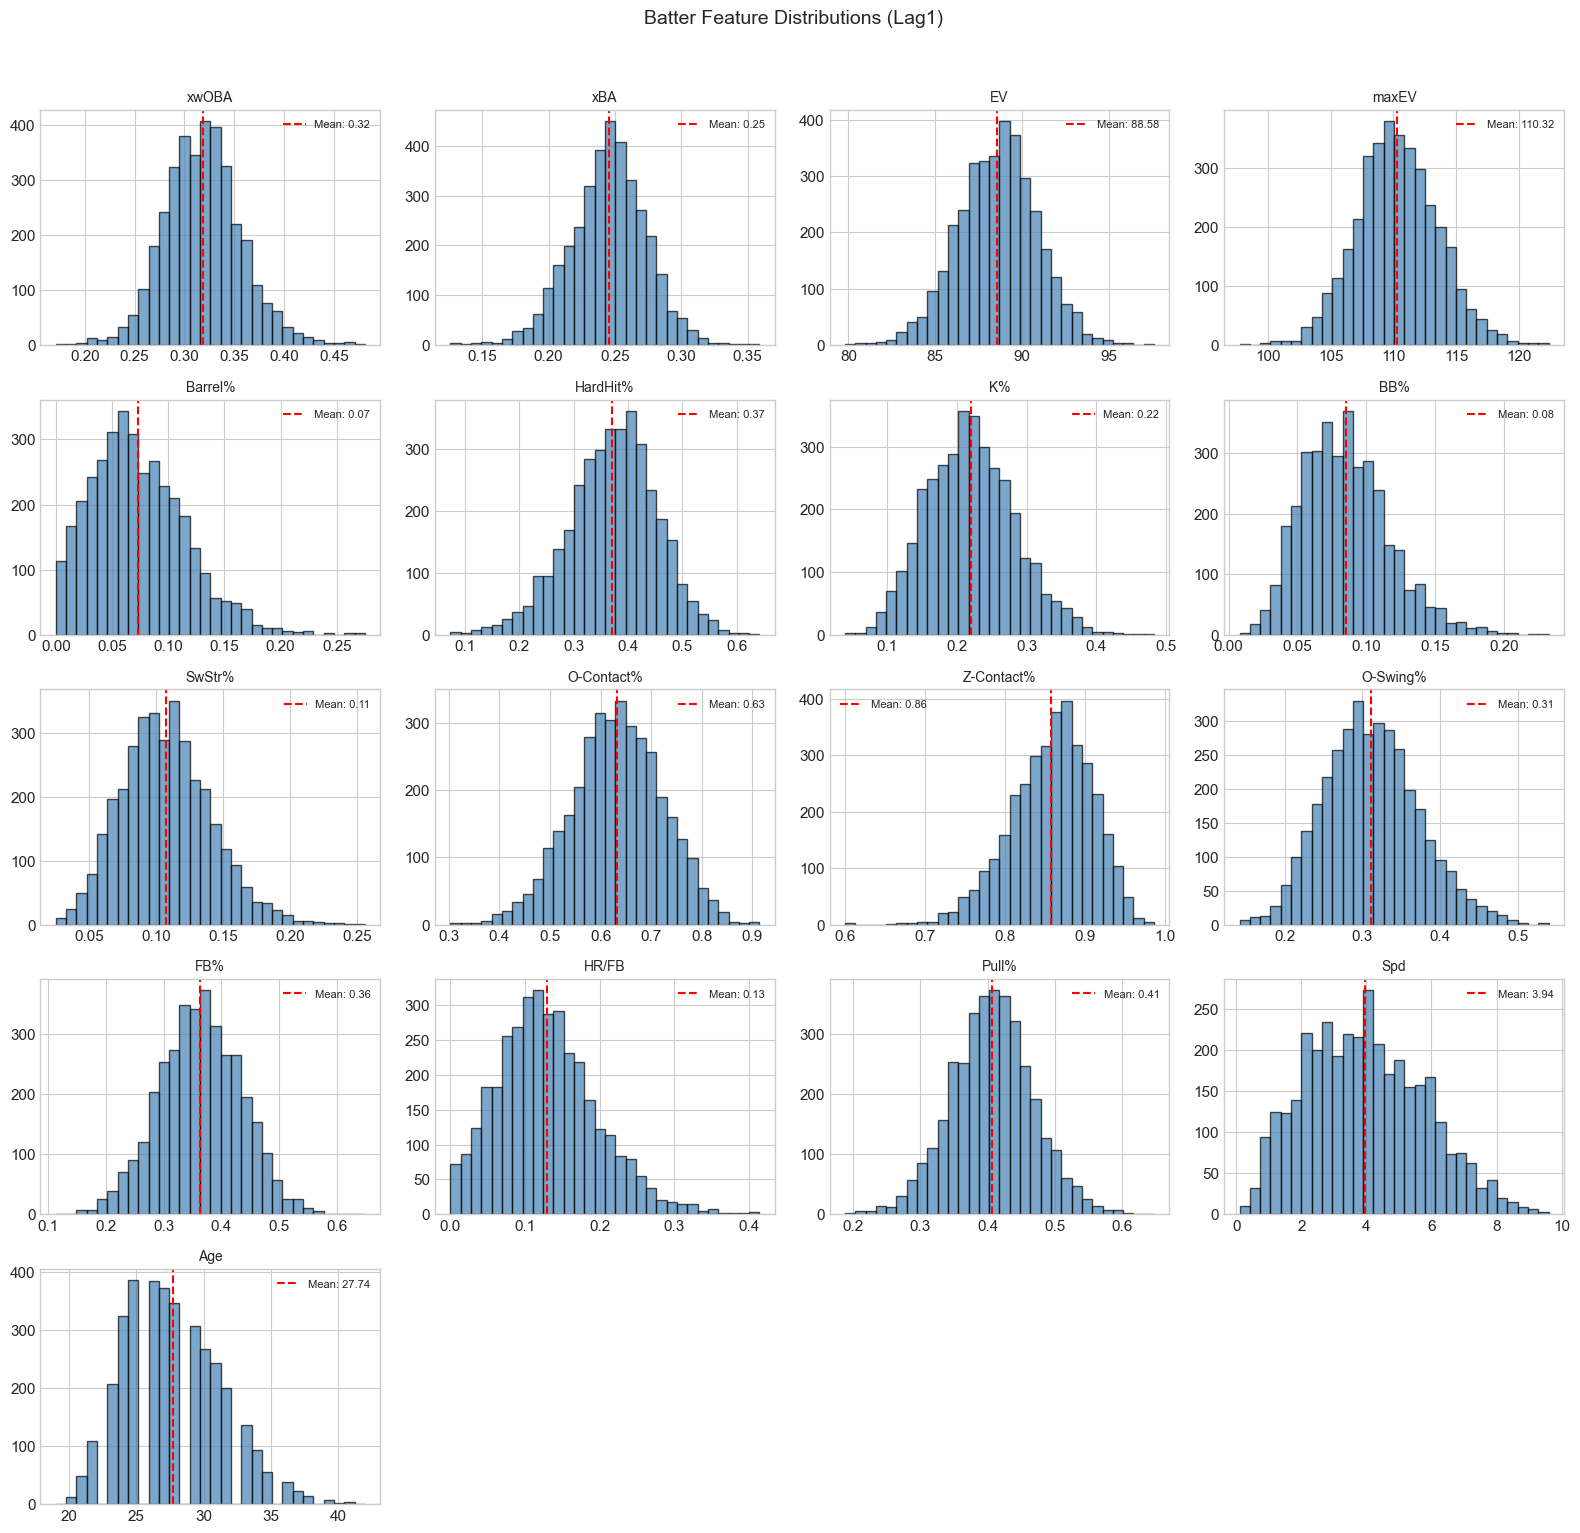

In [3]:
# Batter lag1 feature distributions
batter_lag1 = [f for f in batter_features if '_lag1' in f]

n_features = len(batter_lag1)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()

for i, feature in enumerate(batter_lag1):
    if feature in batters_df.columns:
        data = batters_df[feature].dropna()
        axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_title(feature.replace('_lag1', ''), fontsize=10)
        axes[i].set_xlabel('')
        # Add mean line
        axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
        axes[i].legend(fontsize=8)

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Batter Feature Distributions (Lag1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/batter_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.2 Correlation Matrix (Full)

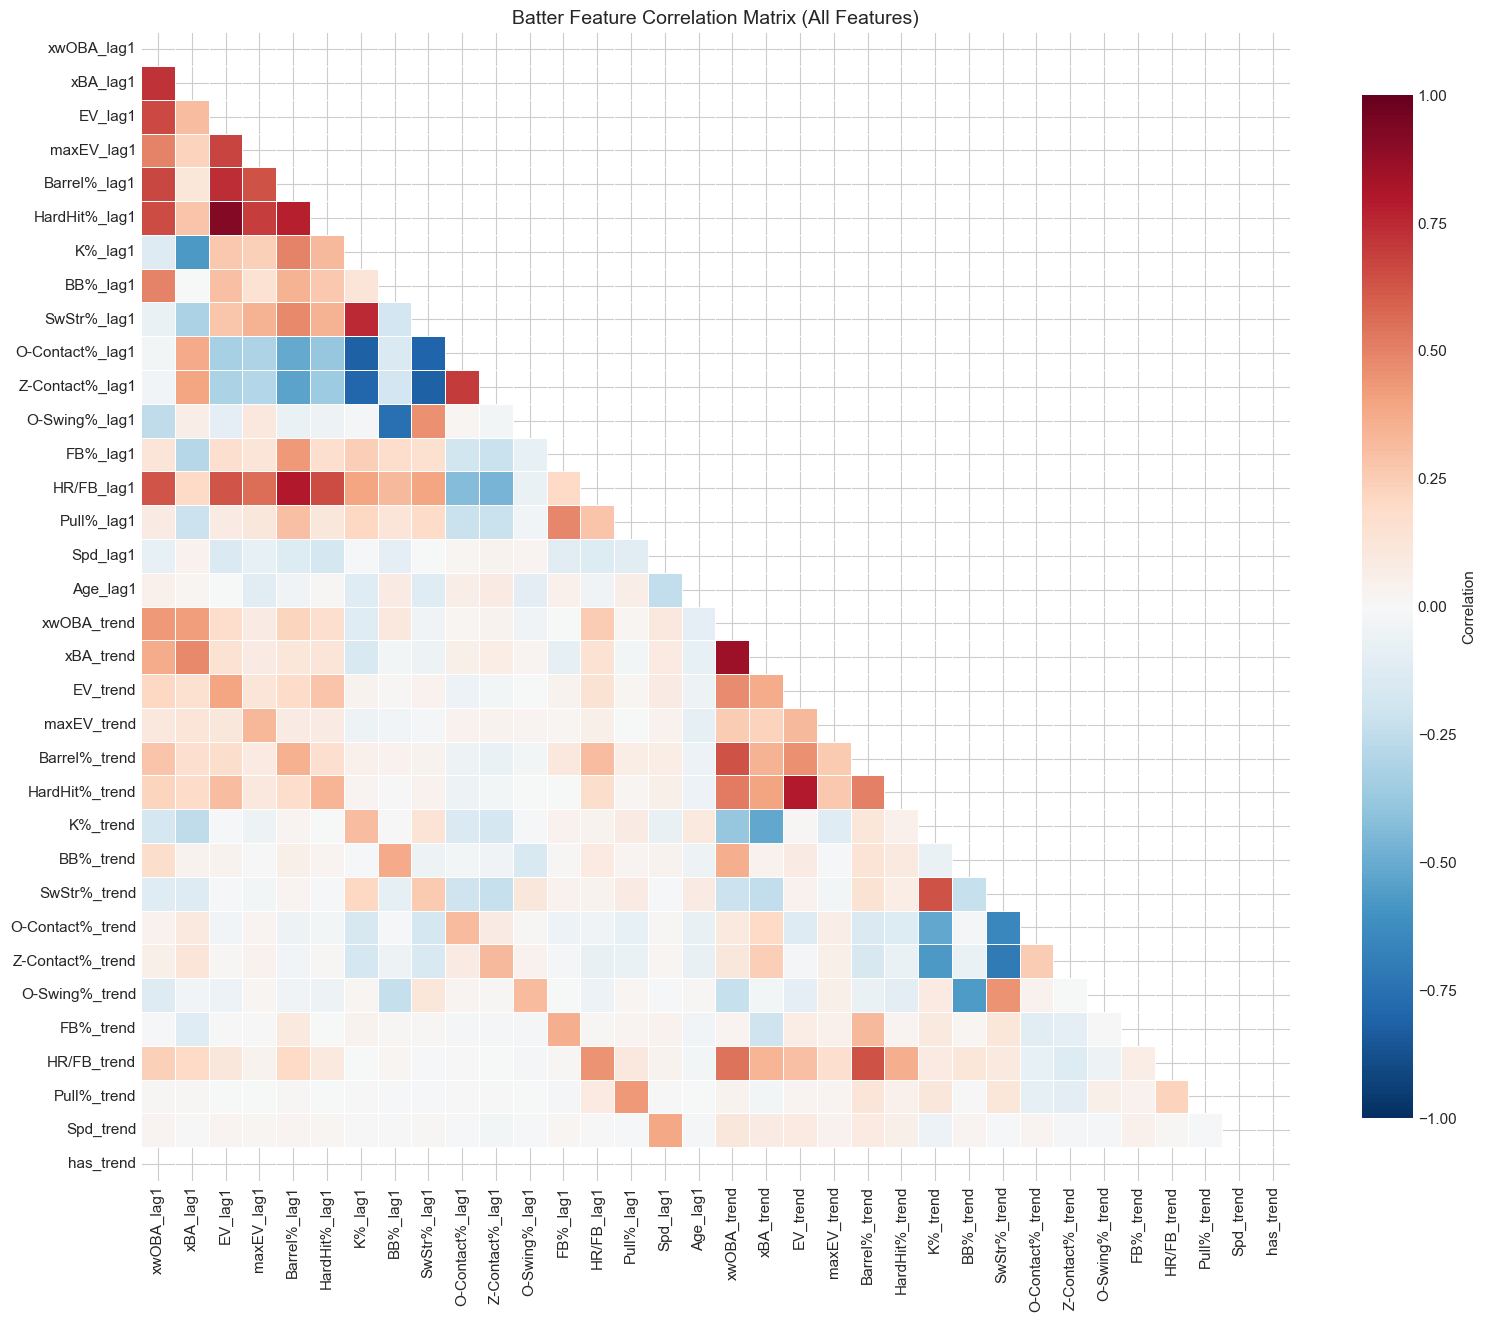

In [4]:
# Full correlation matrix for batter features
available_bat = [f for f in batter_features if f in batters_df.columns]
batter_corr = batters_df[available_bat].dropna().corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(batter_corr, dtype=bool))
sns.heatmap(batter_corr, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, annot=False,
            vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
plt.title('Batter Feature Correlation Matrix (All Features)', fontsize=14)
plt.tight_layout()
plt.savefig('book/_static/images/batter_corr_full.png', dpi=150, bbox_inches='tight')
plt.show()

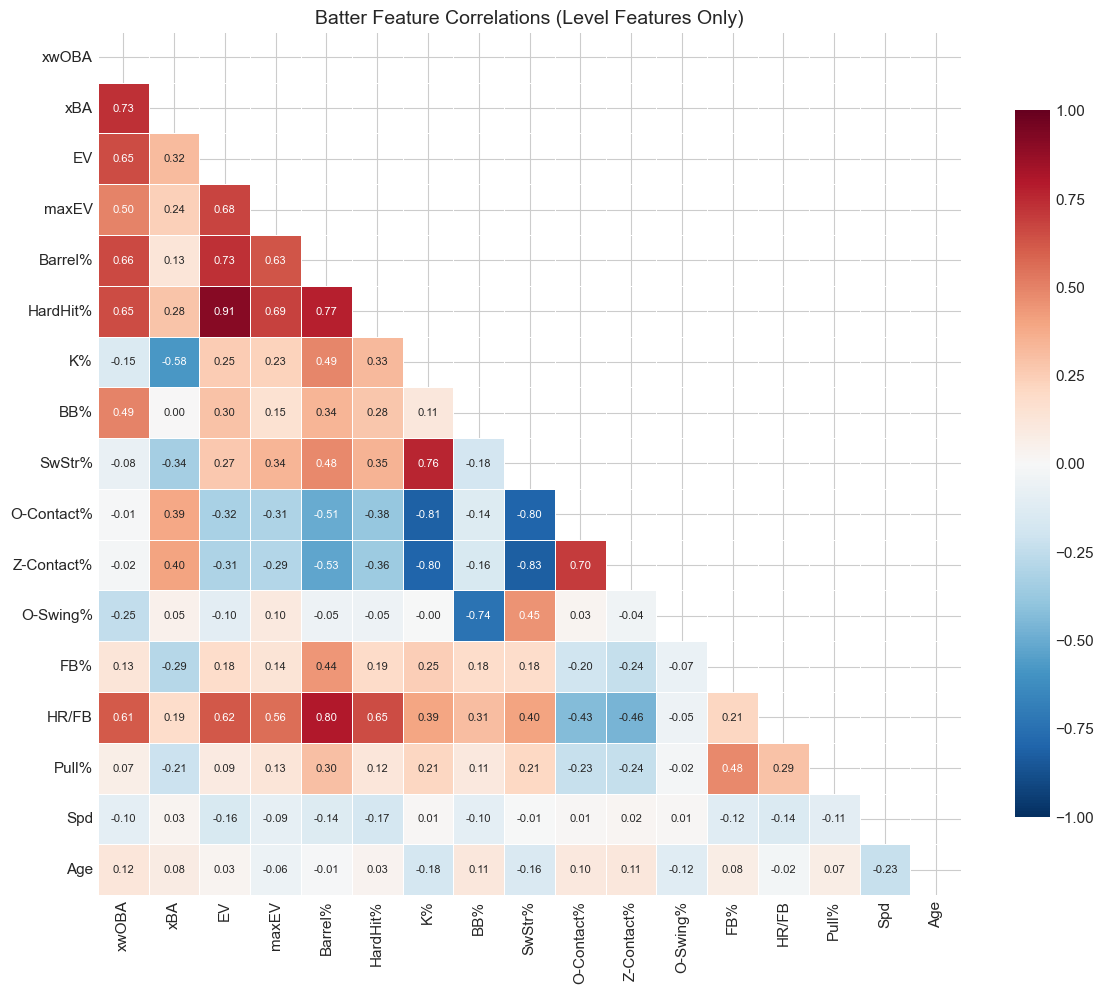

In [5]:
# Correlation matrix for lag1 features only (cleaner view)
batter_lag1_avail = [f for f in batter_lag1 if f in batters_df.columns]
batter_lag1_corr = batters_df[batter_lag1_avail].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(batter_lag1_corr, dtype=bool))

# Clean labels
labels = [f.replace('_lag1', '') for f in batter_lag1_corr.columns]

sns.heatmap(batter_lag1_corr, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, annot=True, fmt='.2f',
            annot_kws={'size': 8},
            xticklabels=labels, yticklabels=labels,
            vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Batter Feature Correlations (Level Features Only)', fontsize=14)
plt.tight_layout()
plt.savefig('book/_static/images/batter_corr_lag1.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 Feature vs Target Scatter Plots

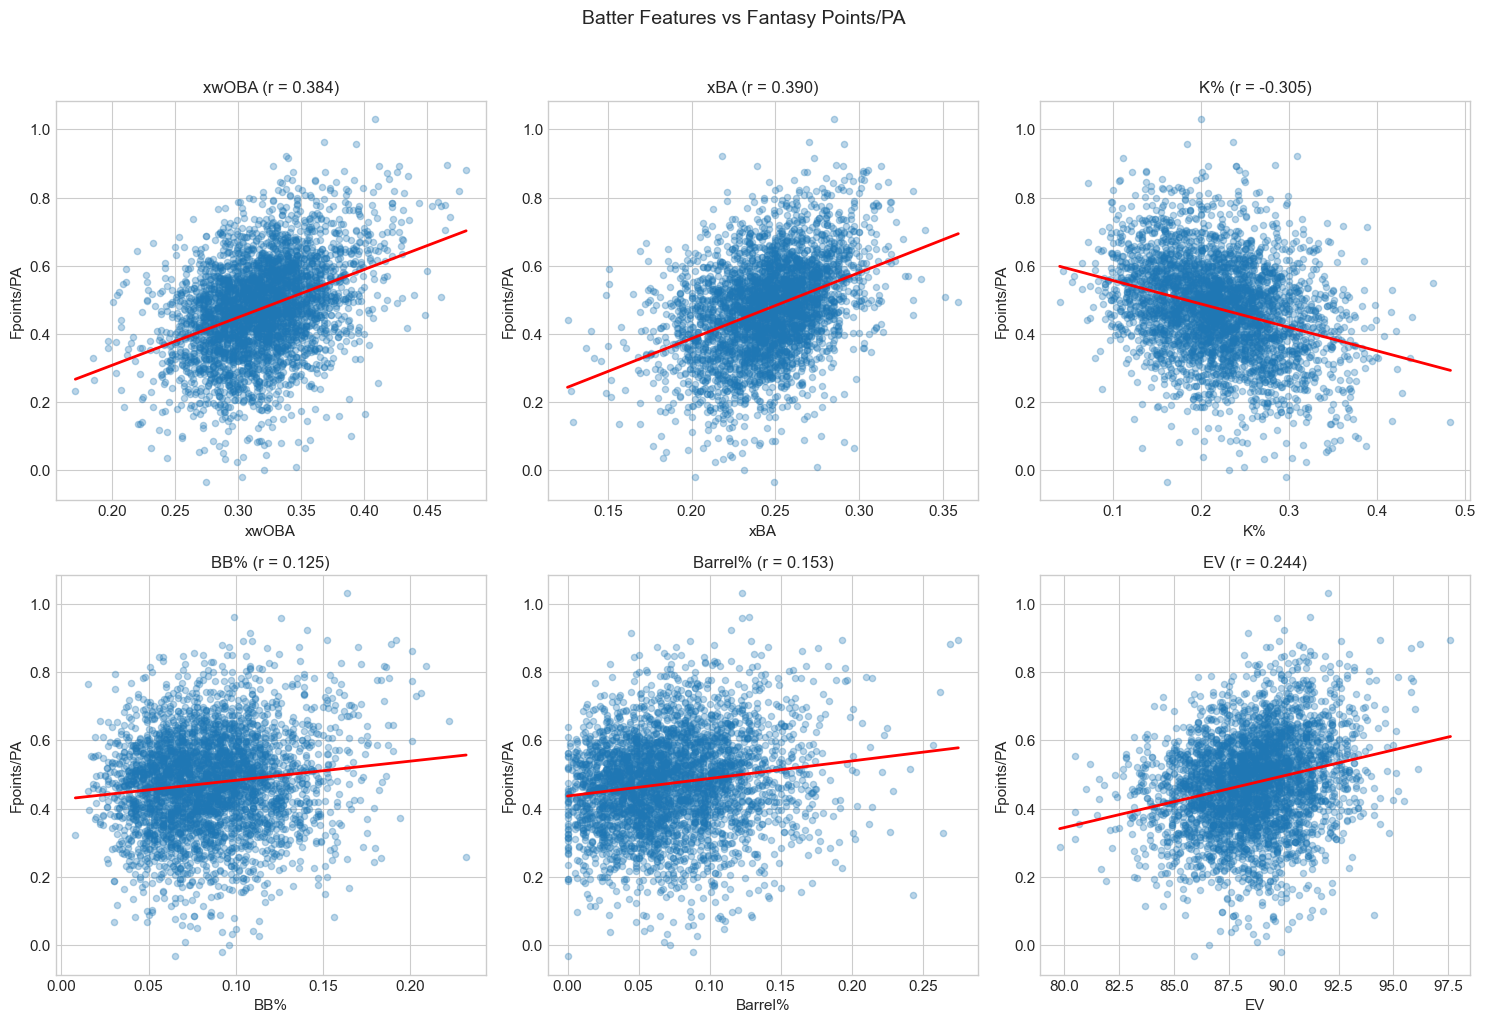

In [6]:
# Top features vs target
top_batter_features = ['xwOBA_lag1', 'xBA_lag1', 'K%_lag1', 'BB%_lag1', 'Barrel%_lag1', 'EV_lag1']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_batter_features):
    if feature in batters_df.columns:
        data = batters_df[[feature, 'Fpoints_PA']].dropna()
        axes[i].scatter(data[feature], data['Fpoints_PA'], alpha=0.3, s=20)
        
        # Add regression line
        z = np.polyfit(data[feature], data['Fpoints_PA'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data[feature].min(), data[feature].max(), 100)
        axes[i].plot(x_line, p(x_line), 'r-', linewidth=2)
        
        # Correlation
        corr = data[feature].corr(data['Fpoints_PA'])
        axes[i].set_title(f"{feature.replace('_lag1', '')} (r = {corr:.3f})", fontsize=12)
        axes[i].set_xlabel(feature.replace('_lag1', ''))
        axes[i].set_ylabel('Fpoints/PA')

plt.suptitle('Batter Features vs Fantasy Points/PA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/batter_scatter_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Pairplot (Key Features)

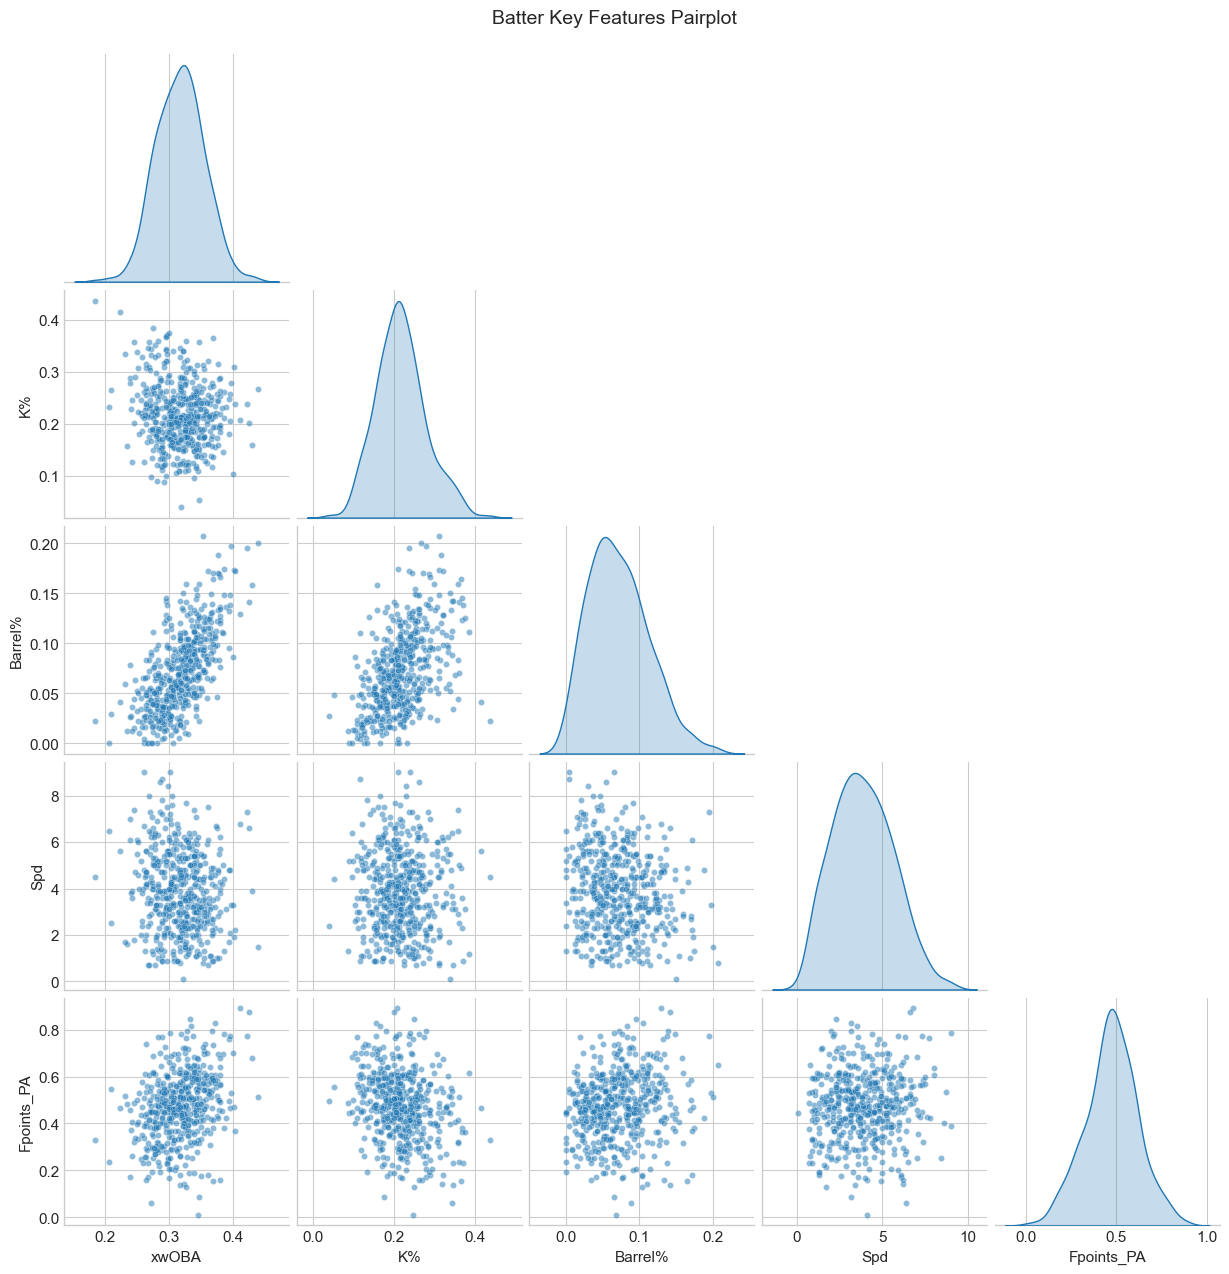

In [7]:
# Pairplot for key batter features
key_batter = ['xwOBA_lag1', 'K%_lag1', 'Barrel%_lag1', 'Spd_lag1', 'Fpoints_PA']
key_batter_avail = [f for f in key_batter if f in batters_df.columns]

pairplot_data = batters_df[key_batter_avail].dropna().sample(min(500, len(batters_df)), random_state=42)

# Rename for cleaner labels
pairplot_data.columns = [c.replace('_lag1', '') for c in pairplot_data.columns]

g = sns.pairplot(pairplot_data, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20},
                 corner=True)
g.fig.suptitle('Batter Key Features Pairplot', y=1.02, fontsize=14)
plt.savefig('book/_static/images/batter_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.5 Year-over-Year Stability

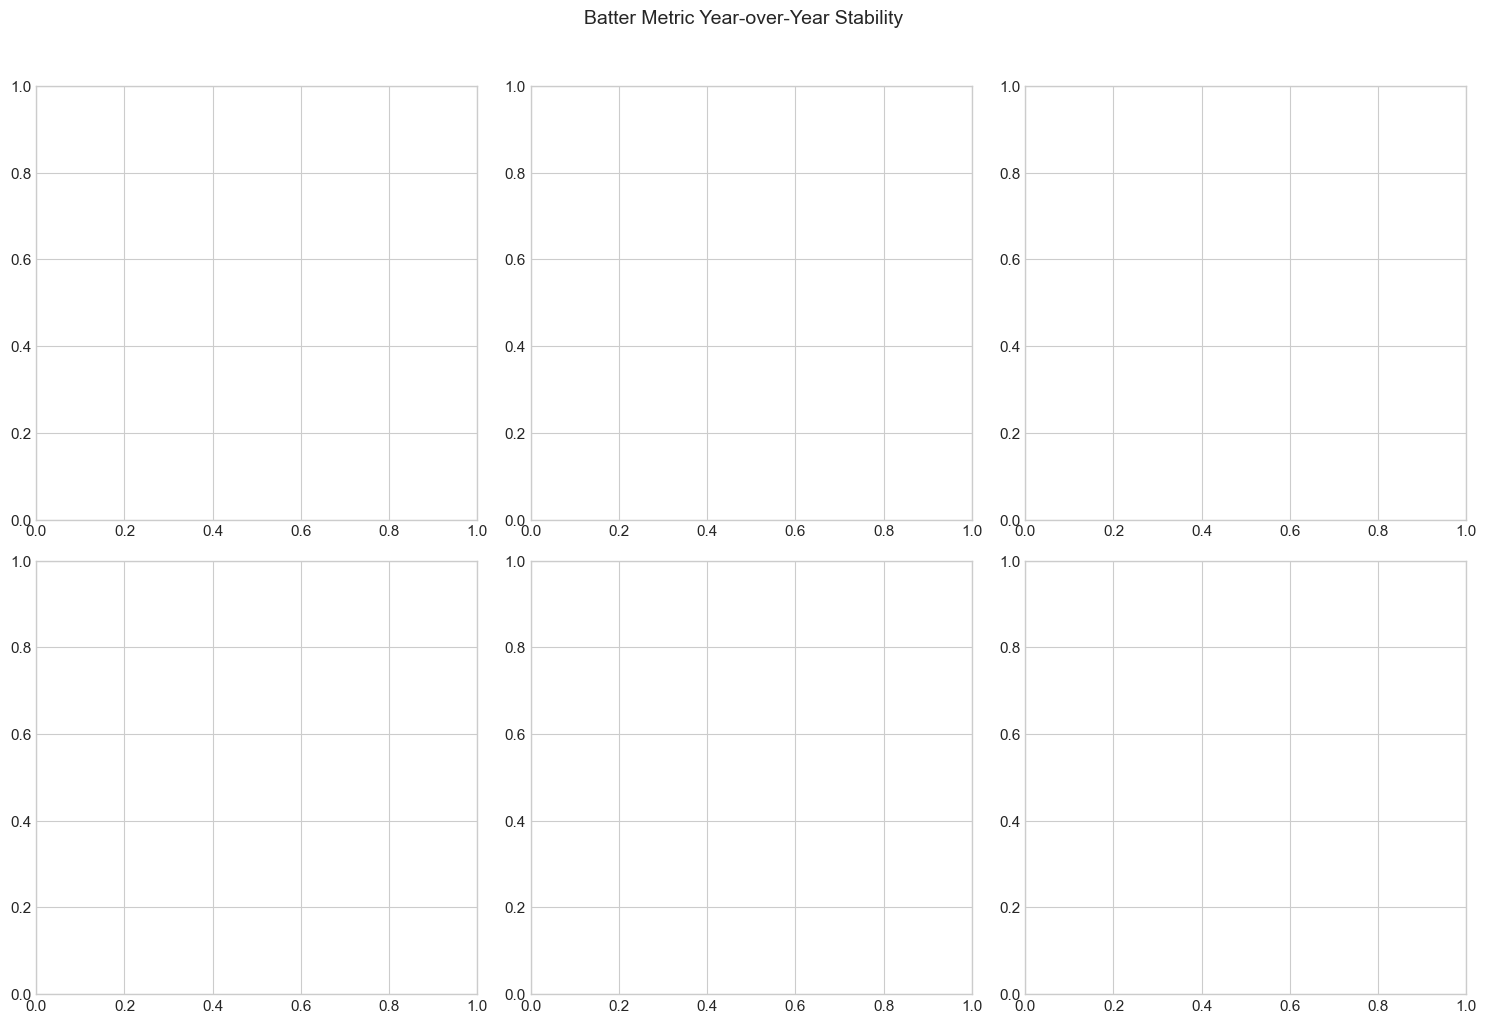

In [8]:
# Year-over-year correlation (lag1 vs lag2)
yoy_features = ['xwOBA', 'K%', 'BB%', 'Barrel%', 'EV', 'SwStr%']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, base in enumerate(yoy_features):
    lag1 = f"{base}_lag1"
    lag2 = f"{base}_lag2"
    
    if lag1 in batters_df.columns and lag2 in batters_df.columns:
        data = batters_df[[lag1, lag2]].dropna()
        axes[i].scatter(data[lag2], data[lag1], alpha=0.3, s=20)
        
        # Add diagonal line (perfect stability)
        lims = [min(data[lag1].min(), data[lag2].min()), max(data[lag1].max(), data[lag2].max())]
        axes[i].plot(lims, lims, 'r--', linewidth=2, label='Perfect stability')
        
        # Correlation
        corr = data[lag1].corr(data[lag2])
        axes[i].set_title(f"{base} (YoY r = {corr:.3f})", fontsize=12)
        axes[i].set_xlabel(f'{base} (Year N-1)')
        axes[i].set_ylabel(f'{base} (Year N)')
        axes[i].legend()

plt.suptitle('Batter Metric Year-over-Year Stability', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/batter_yoy_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.6 Trend Feature Distributions

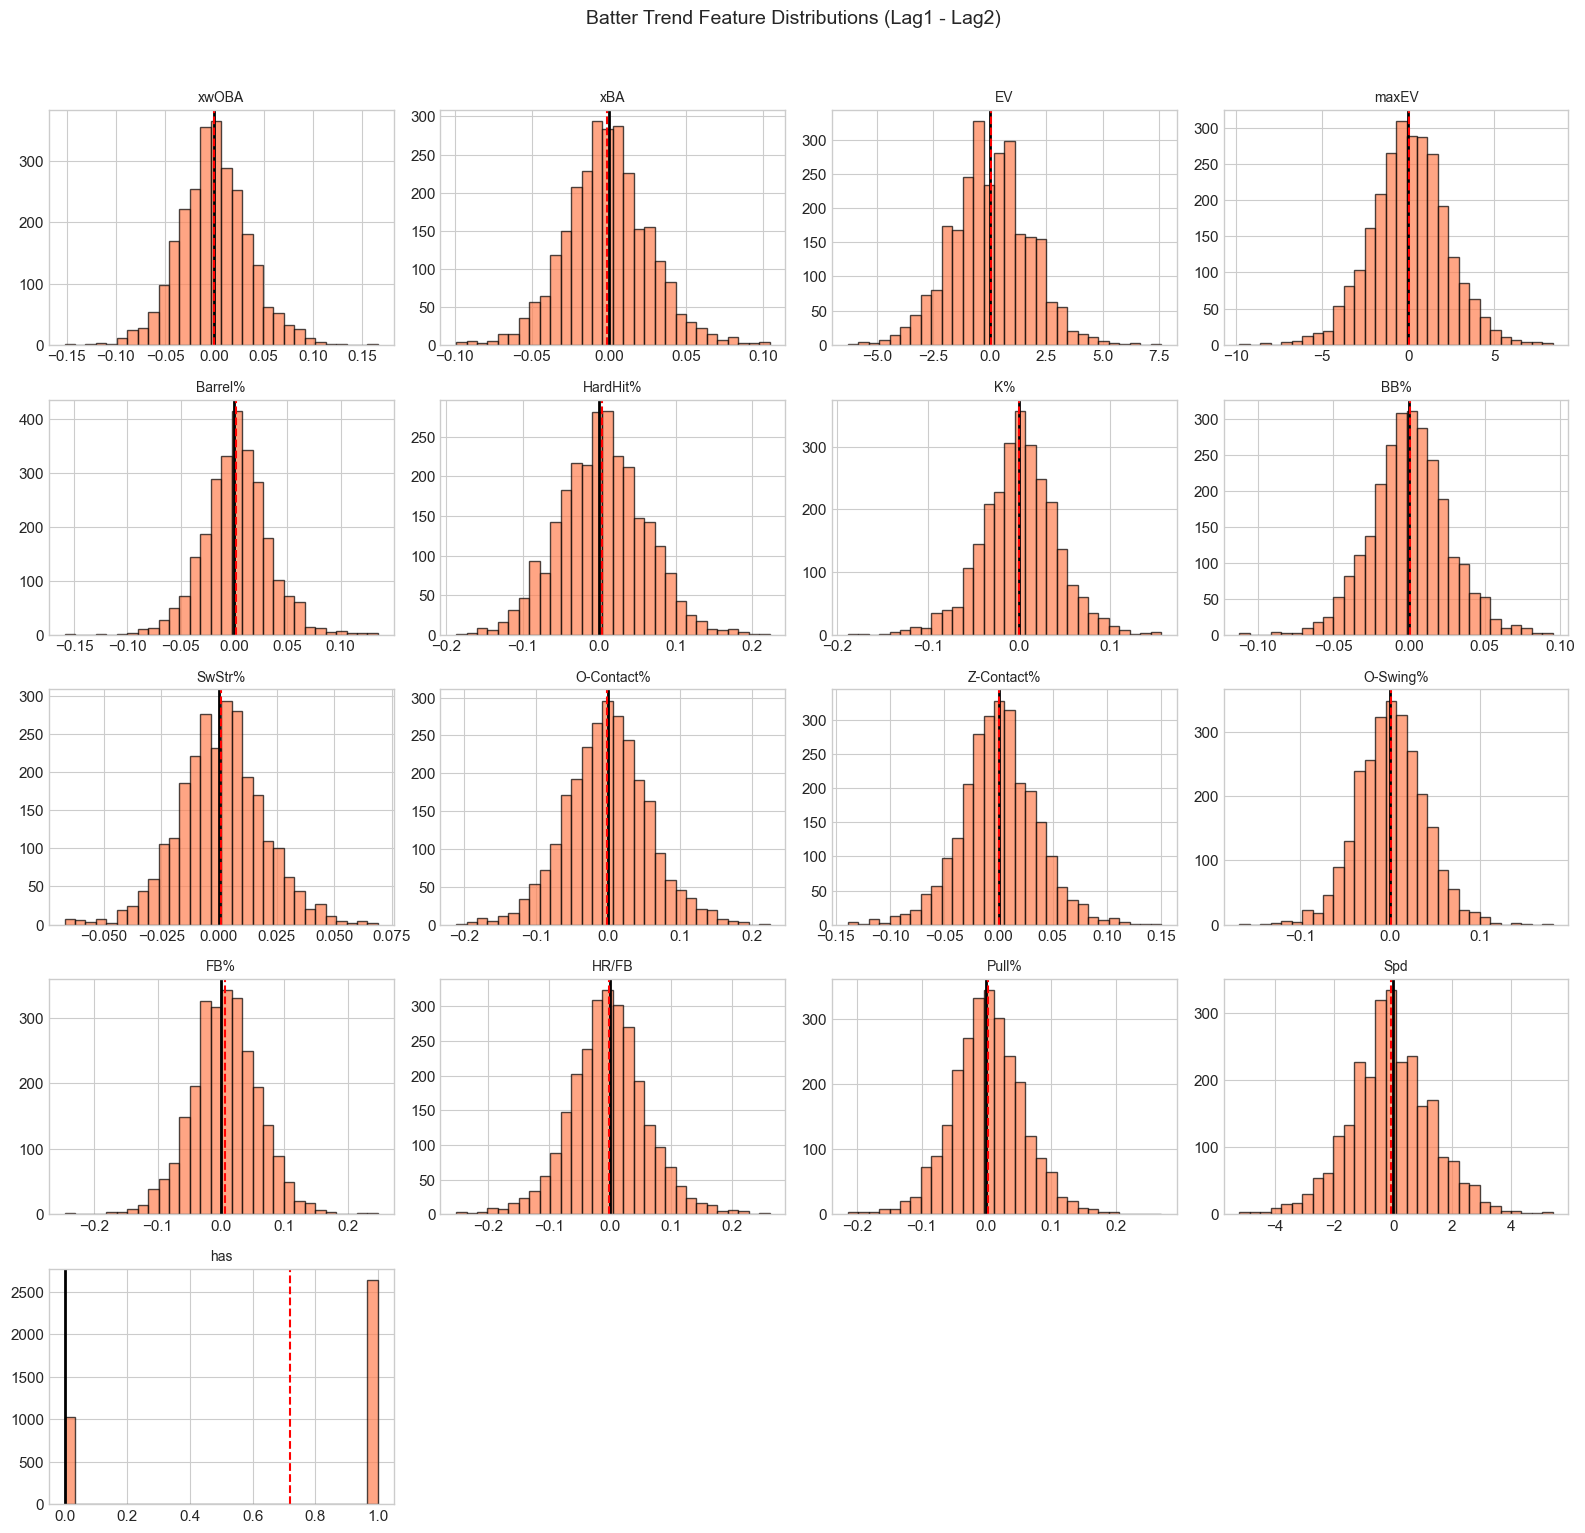

In [9]:
# Trend feature distributions (centered around 0?)
batter_trend = [f for f in batter_features if '_trend' in f]

n_features = len(batter_trend)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()

for i, feature in enumerate(batter_trend):
    if feature in batters_df.columns:
        data = batters_df[feature].dropna()
        axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7, color='coral')
        axes[i].set_title(feature.replace('_trend', ''), fontsize=10)
        axes[i].axvline(0, color='black', linestyle='-', linewidth=2)
        axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Batter Trend Feature Distributions (Lag1 - Lag2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/batter_trend_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.7 Hierarchical Clustering Dendrogram

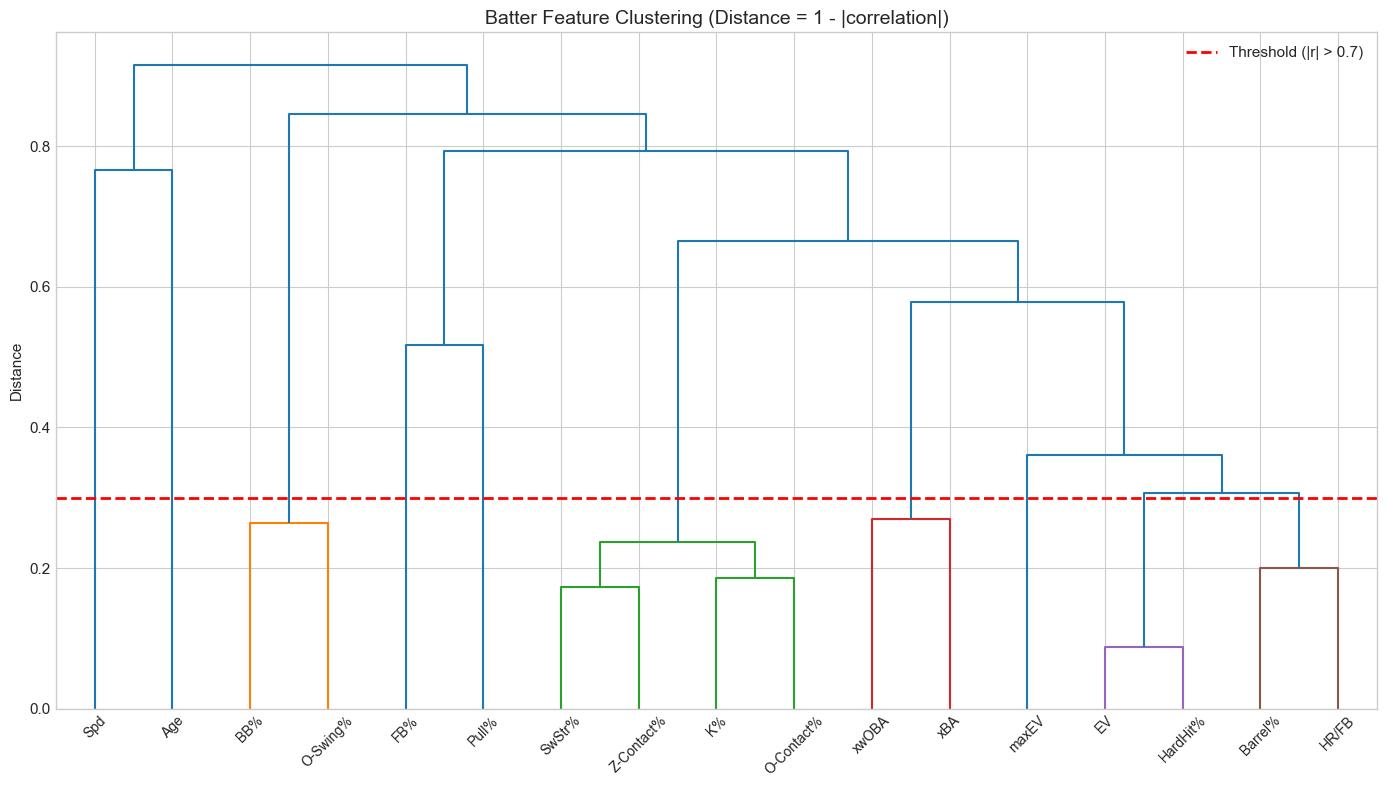

In [10]:
# Dendrogram for batter lag1 features
batter_lag1_data = batters_df[batter_lag1_avail].dropna()
corr = batter_lag1_data.corr()

# Distance = 1 - |correlation|
dissimilarity = 1 - np.abs(corr)
np.fill_diagonal(dissimilarity.values, 0)

linkage_matrix = linkage(squareform(dissimilarity), method='average')

fig, ax = plt.subplots(figsize=(14, 8))
labels = [f.replace('_lag1', '') for f in corr.columns]
dendrogram(linkage_matrix, labels=labels, leaf_rotation=45, leaf_font_size=10,
           color_threshold=0.3, ax=ax)
ax.set_title('Batter Feature Clustering (Distance = 1 - |correlation|)', fontsize=14)
ax.set_ylabel('Distance')
ax.axhline(y=0.3, color='r', linestyle='--', linewidth=2, label='Threshold (|r| > 0.7)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('book/_static/images/batter_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.8 Feature by Season

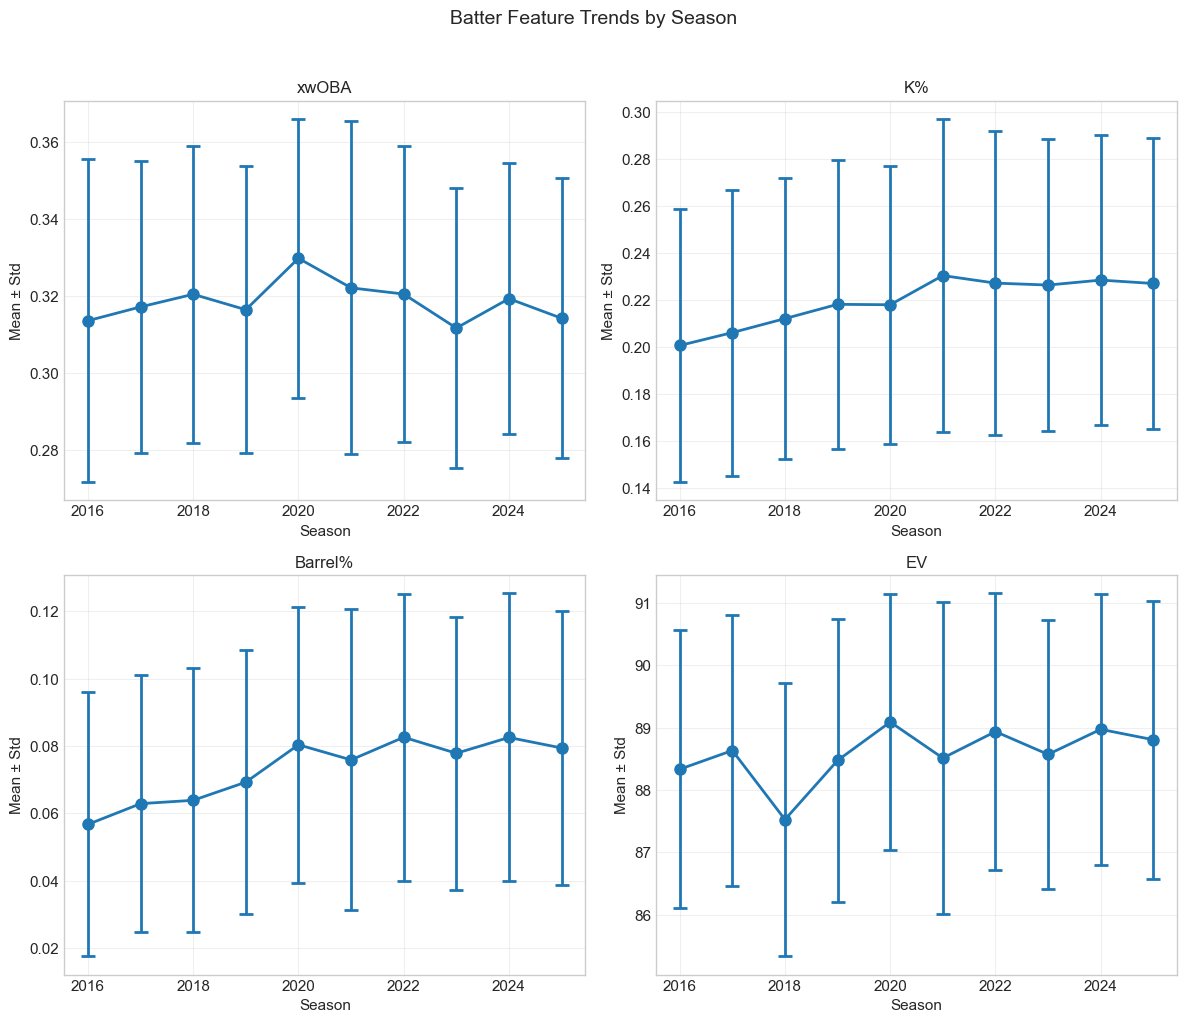

In [11]:
# Feature means by season
features_to_plot = ['xwOBA_lag1', 'K%_lag1', 'Barrel%_lag1', 'EV_lag1']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    if feature in batters_df.columns:
        season_means = batters_df.groupby('Season')[feature].mean()
        season_stds = batters_df.groupby('Season')[feature].std()
        
        axes[i].errorbar(season_means.index, season_means.values, yerr=season_stds.values,
                        marker='o', capsize=5, capthick=2, linewidth=2, markersize=8)
        axes[i].set_title(feature.replace('_lag1', ''), fontsize=12)
        axes[i].set_xlabel('Season')
        axes[i].set_ylabel('Mean ± Std')
        axes[i].grid(True, alpha=0.3)

plt.suptitle('Batter Feature Trends by Season', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/batter_season_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.9 Age Curves

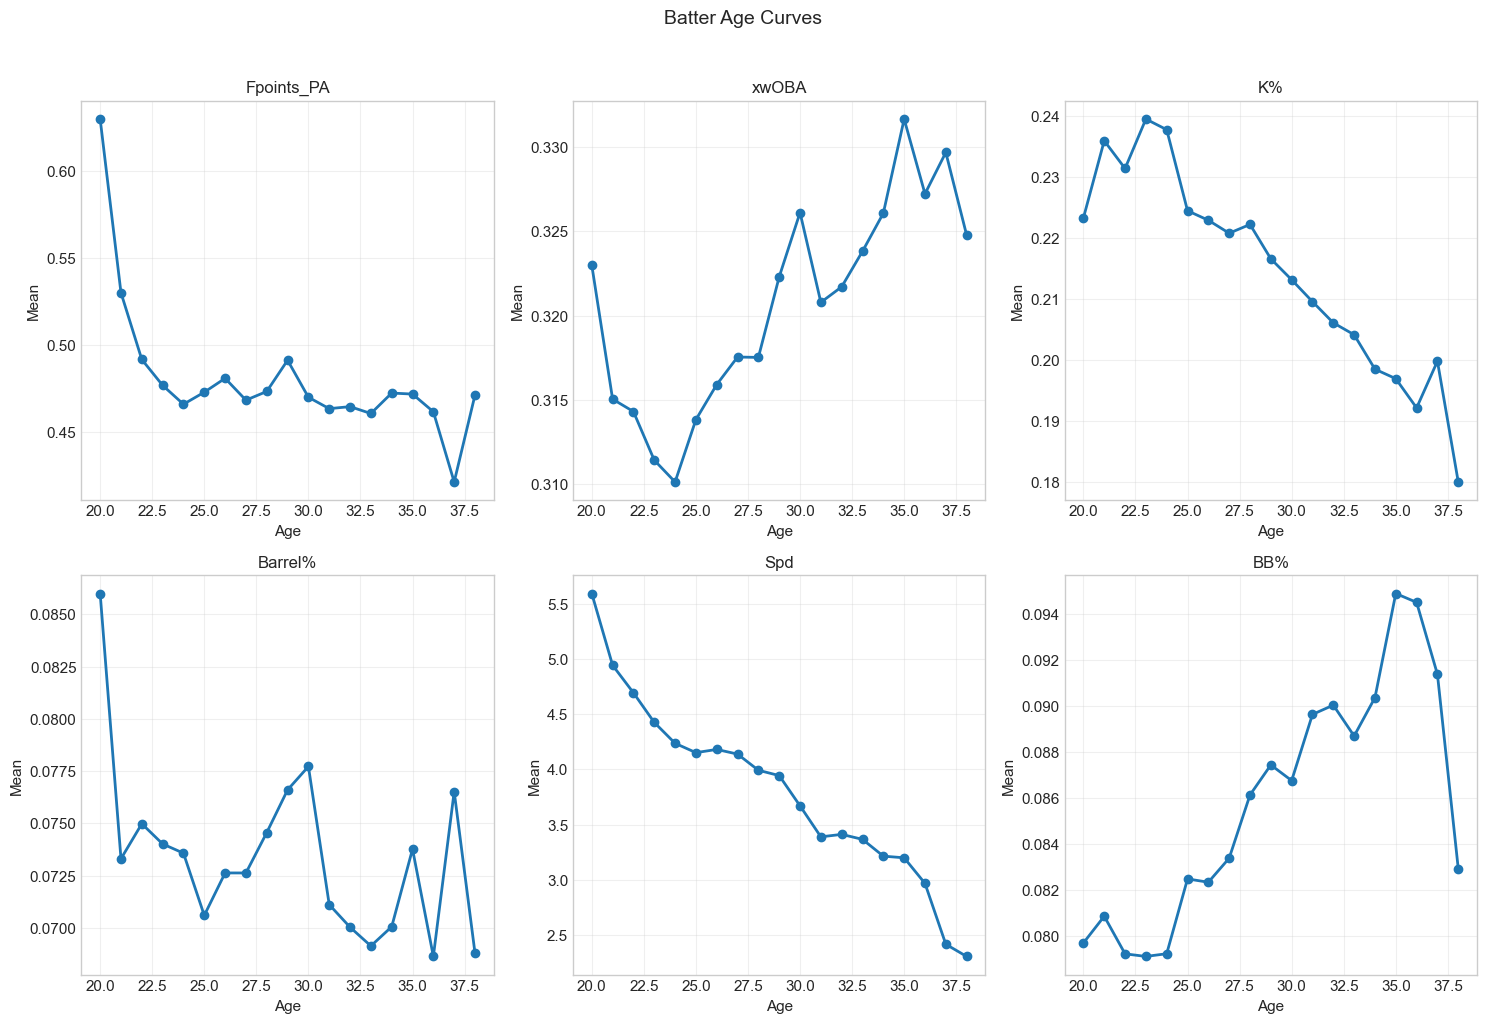

In [12]:
# Age curves for key metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics = ['Fpoints_PA', 'xwOBA_lag1', 'K%_lag1', 'Barrel%_lag1', 'Spd_lag1', 'BB%_lag1']

for i, metric in enumerate(metrics):
    if metric in batters_df.columns and 'Age_lag1' in batters_df.columns:
        data = batters_df[['Age_lag1', metric]].dropna()
        age_means = data.groupby('Age_lag1')[metric].mean()
        age_counts = data.groupby('Age_lag1')[metric].count()
        
        # Filter to ages with enough data
        valid_ages = age_counts[age_counts >= 10].index
        age_means = age_means[age_means.index.isin(valid_ages)]
        
        axes[i].plot(age_means.index, age_means.values, marker='o', linewidth=2, markersize=6)
        axes[i].set_title(metric.replace('_lag1', ''), fontsize=12)
        axes[i].set_xlabel('Age')
        axes[i].set_ylabel('Mean')
        axes[i].grid(True, alpha=0.3)

plt.suptitle('Batter Age Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/batter_age_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Part 2: Pitcher Feature Visualizations
---

## 2.1 Feature Distributions (Histograms)

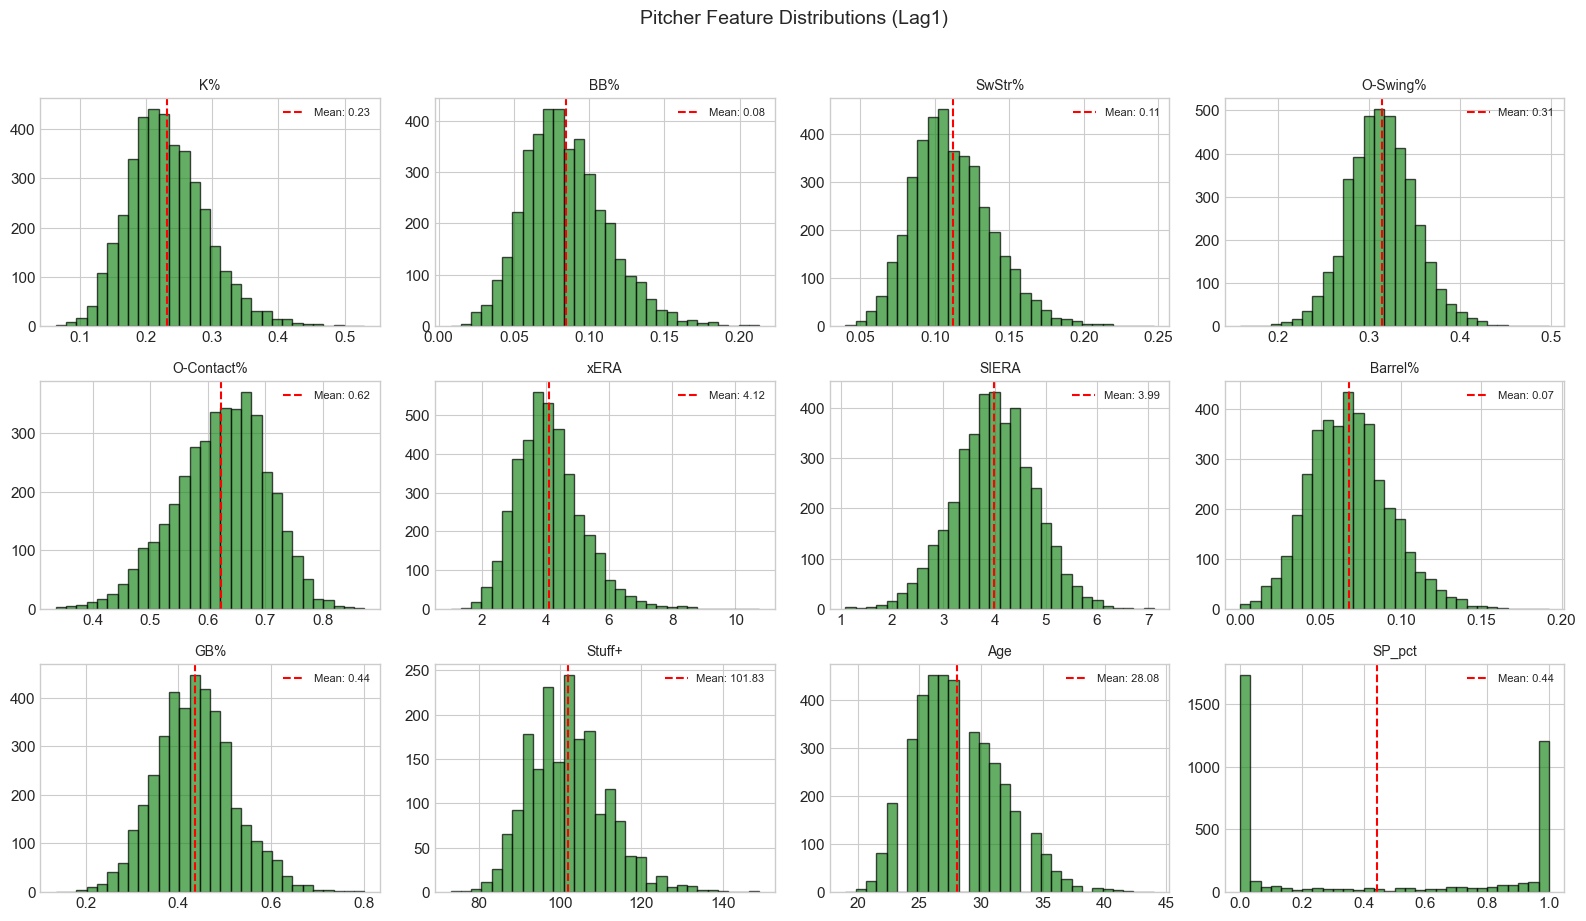

In [13]:
# Pitcher lag1 feature distributions
pitcher_lag1 = [f for f in pitcher_features if '_lag1' in f]

n_features = len(pitcher_lag1)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()

for i, feature in enumerate(pitcher_lag1):
    if feature in pitchers_df.columns:
        data = pitchers_df[feature].dropna()
        axes[i].hist(data, bins=30, edgecolor='black', alpha=0.7, color='forestgreen')
        axes[i].set_title(feature.replace('_lag1', ''), fontsize=10)
        axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
        axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Pitcher Feature Distributions (Lag1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/pitcher_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.2 Correlation Matrix

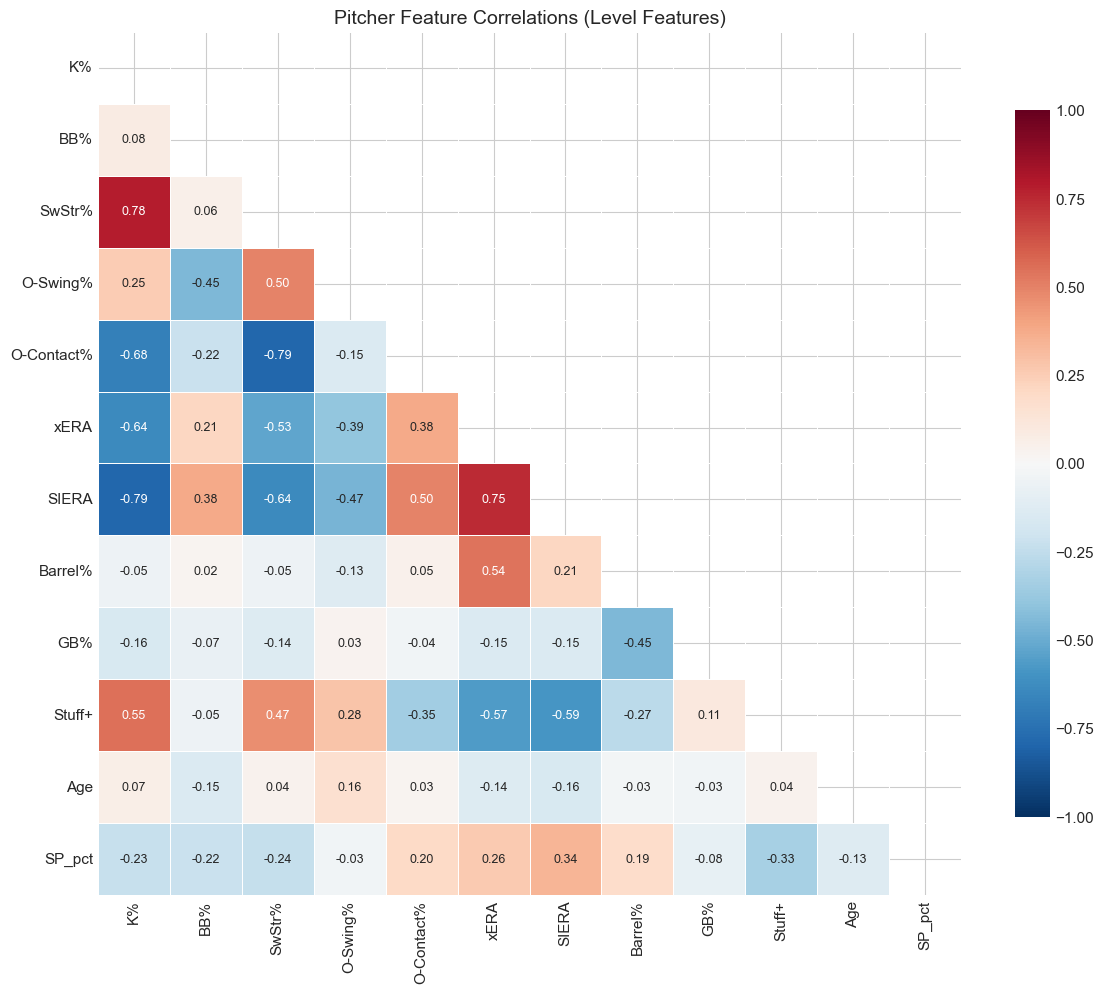

In [14]:
# Correlation matrix for pitcher lag1 features
pitcher_lag1_avail = [f for f in pitcher_lag1 if f in pitchers_df.columns]
pitcher_lag1_corr = pitchers_df[pitcher_lag1_avail].dropna().corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(pitcher_lag1_corr, dtype=bool))

labels = [f.replace('_lag1', '') for f in pitcher_lag1_corr.columns]

sns.heatmap(pitcher_lag1_corr, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, annot=True, fmt='.2f',
            annot_kws={'size': 9},
            xticklabels=labels, yticklabels=labels,
            vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
plt.title('Pitcher Feature Correlations (Level Features)', fontsize=14)
plt.tight_layout()
plt.savefig('book/_static/images/pitcher_corr_lag1.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.3 Feature vs Target Scatter Plots

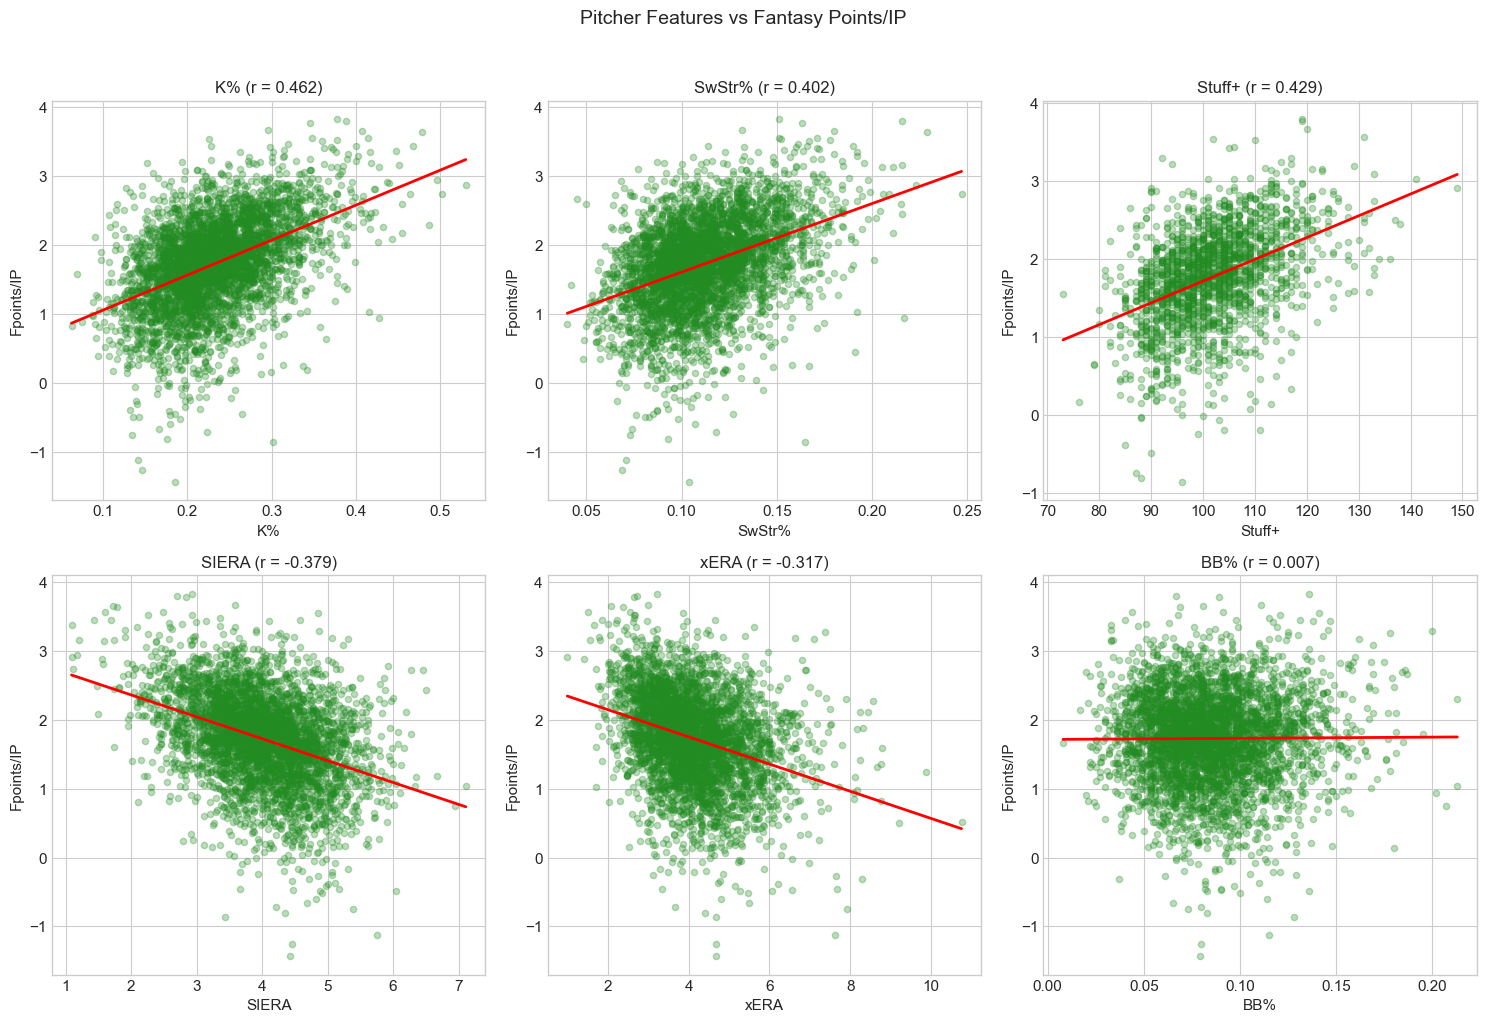

In [15]:
# Top pitcher features vs target
top_pitcher_features = ['K%_lag1', 'SwStr%_lag1', 'Stuff+_lag1', 'SIERA_lag1', 'xERA_lag1', 'BB%_lag1']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_pitcher_features):
    if feature in pitchers_df.columns:
        data = pitchers_df[[feature, 'Fpoints_IP']].dropna()
        axes[i].scatter(data[feature], data['Fpoints_IP'], alpha=0.3, s=20, color='forestgreen')
        
        # Regression line
        z = np.polyfit(data[feature], data['Fpoints_IP'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(data[feature].min(), data[feature].max(), 100)
        axes[i].plot(x_line, p(x_line), 'r-', linewidth=2)
        
        corr = data[feature].corr(data['Fpoints_IP'])
        axes[i].set_title(f"{feature.replace('_lag1', '')} (r = {corr:.3f})", fontsize=12)
        axes[i].set_xlabel(feature.replace('_lag1', ''))
        axes[i].set_ylabel('Fpoints/IP')

plt.suptitle('Pitcher Features vs Fantasy Points/IP', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/pitcher_scatter_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.4 SP vs RP Comparison

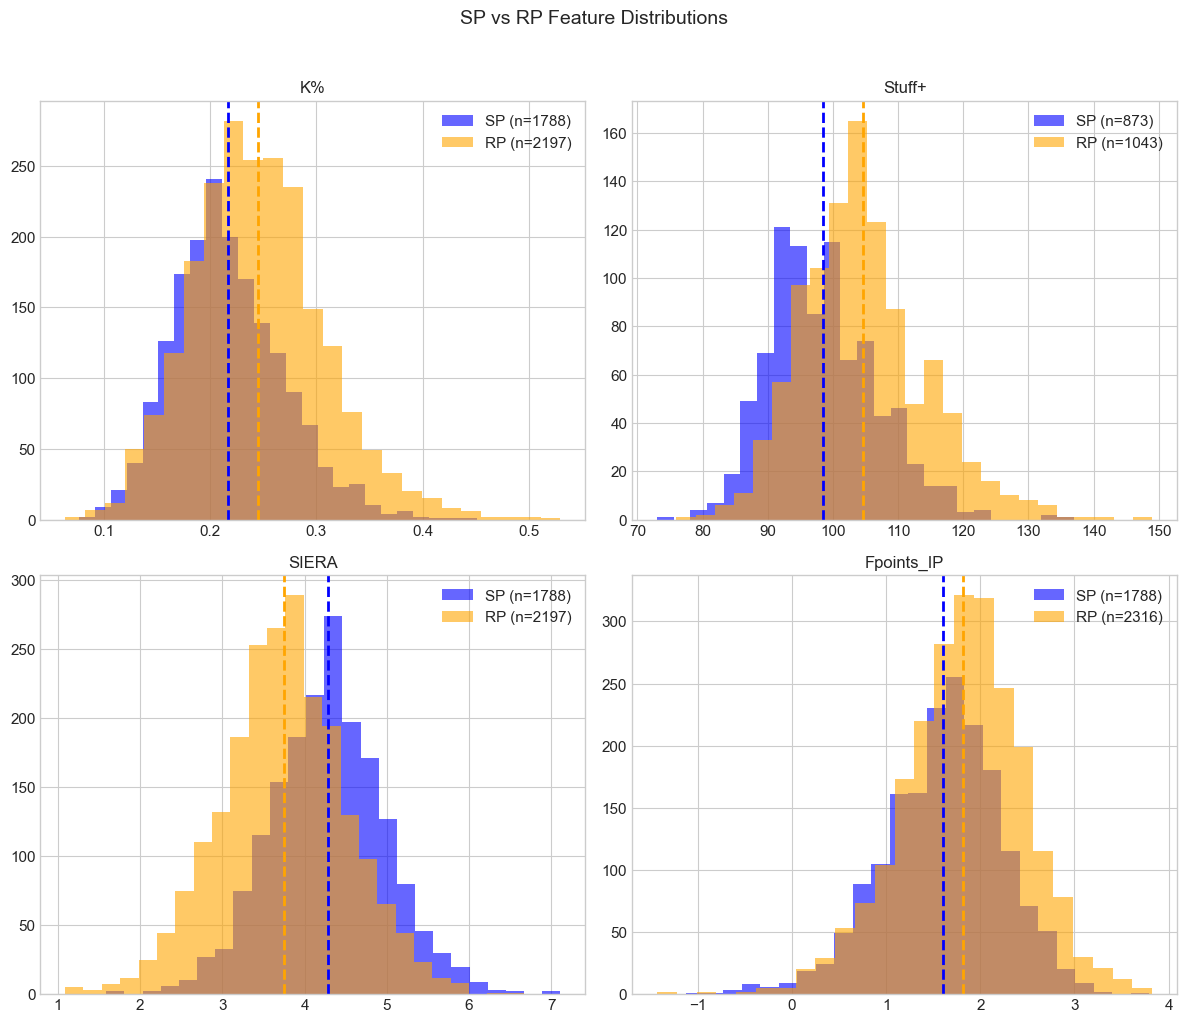

In [16]:
# Compare SP vs RP distributions
if 'SP_pct_lag1' in pitchers_df.columns:
    pitchers_df['Role'] = pitchers_df['SP_pct_lag1'].apply(lambda x: 'SP' if x > 0.5 else 'RP')
    
    features_compare = ['K%_lag1', 'Stuff+_lag1', 'SIERA_lag1', 'Fpoints_IP']
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, feature in enumerate(features_compare):
        if feature in pitchers_df.columns:
            sp_data = pitchers_df[pitchers_df['Role'] == 'SP'][feature].dropna()
            rp_data = pitchers_df[pitchers_df['Role'] == 'RP'][feature].dropna()
            
            axes[i].hist(sp_data, bins=25, alpha=0.6, label=f'SP (n={len(sp_data)})', color='blue')
            axes[i].hist(rp_data, bins=25, alpha=0.6, label=f'RP (n={len(rp_data)})', color='orange')
            axes[i].set_title(feature.replace('_lag1', ''), fontsize=12)
            axes[i].legend()
            axes[i].axvline(sp_data.mean(), color='blue', linestyle='--', linewidth=2)
            axes[i].axvline(rp_data.mean(), color='orange', linestyle='--', linewidth=2)
    
    plt.suptitle('SP vs RP Feature Distributions', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('book/_static/images/pitcher_sp_vs_rp.png', dpi=150, bbox_inches='tight')
    plt.show()

## 2.5 Pitcher Dendrogram

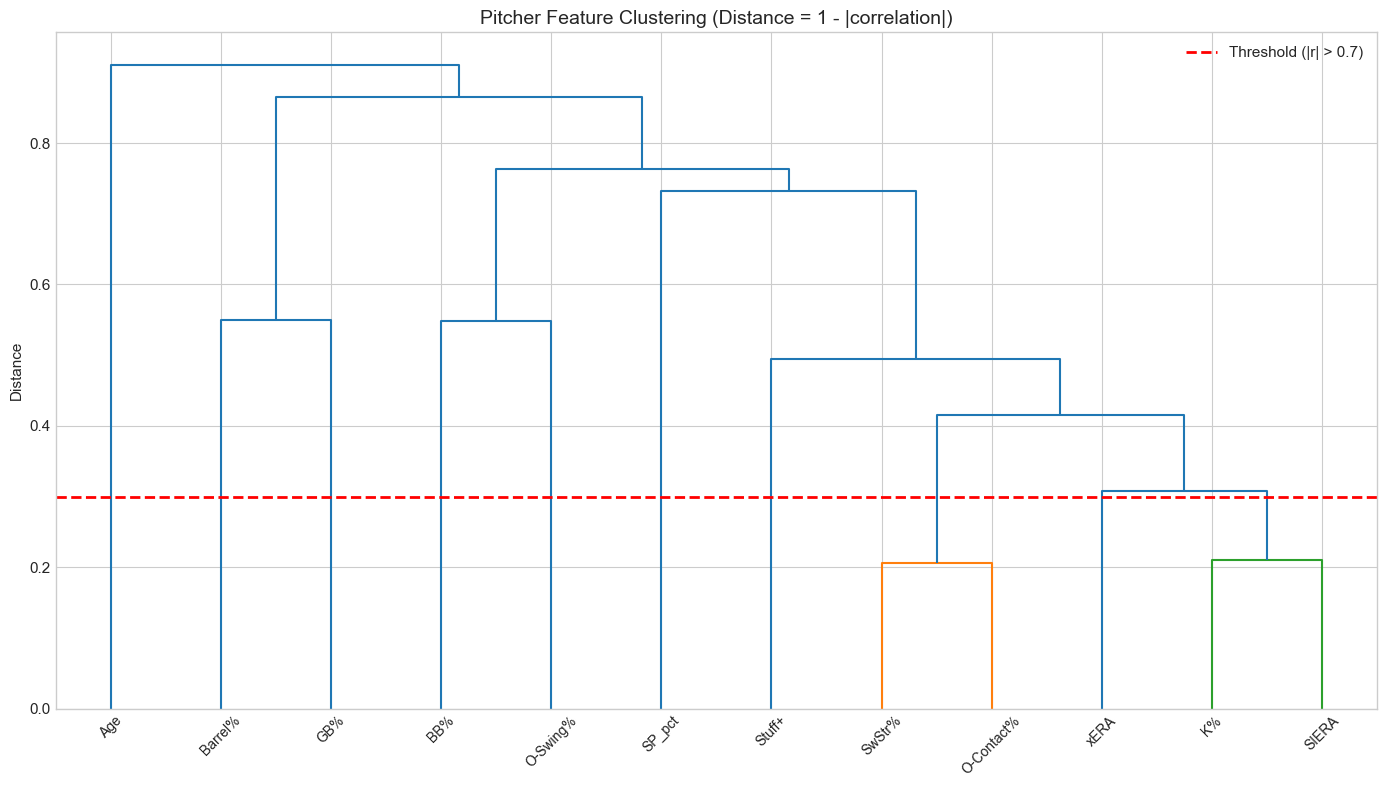

In [17]:
# Dendrogram for pitcher features
pitcher_lag1_data = pitchers_df[pitcher_lag1_avail].dropna()
corr_pit = pitcher_lag1_data.corr()

dissimilarity_pit = 1 - np.abs(corr_pit)
np.fill_diagonal(dissimilarity_pit.values, 0)

linkage_pit = linkage(squareform(dissimilarity_pit), method='average')

fig, ax = plt.subplots(figsize=(14, 8))
labels_pit = [f.replace('_lag1', '') for f in corr_pit.columns]
dendrogram(linkage_pit, labels=labels_pit, leaf_rotation=45, leaf_font_size=10,
           color_threshold=0.3, ax=ax)
ax.set_title('Pitcher Feature Clustering (Distance = 1 - |correlation|)', fontsize=14)
ax.set_ylabel('Distance')
ax.axhline(y=0.3, color='r', linestyle='--', linewidth=2, label='Threshold (|r| > 0.7)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('book/_static/images/pitcher_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.6 Pitcher Age Curves

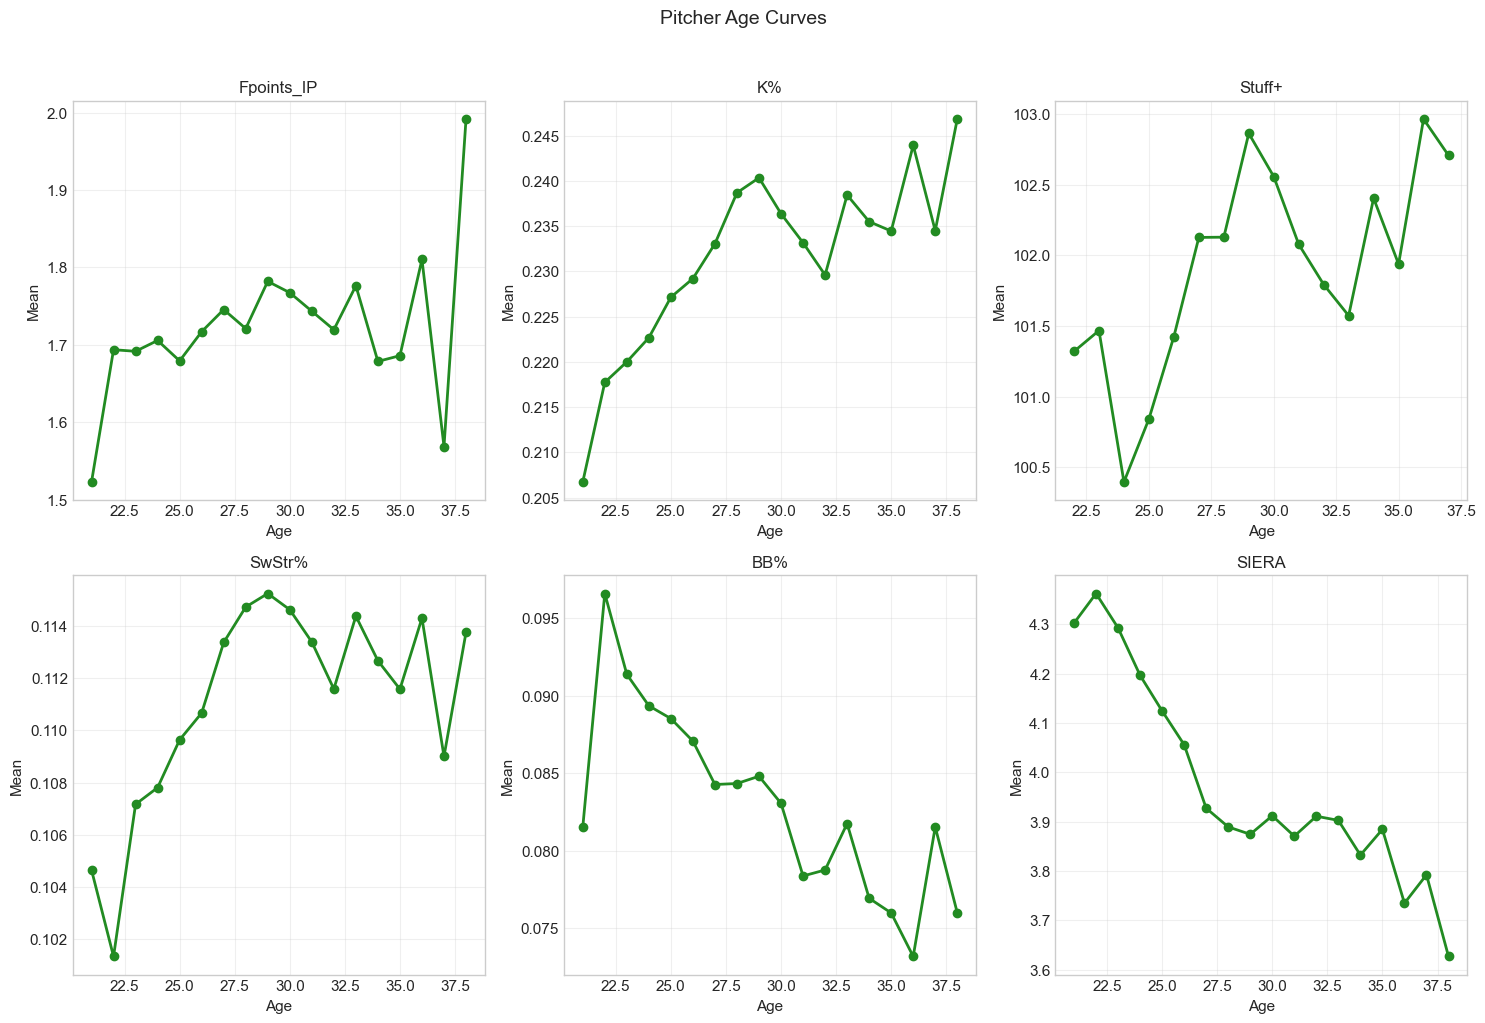

In [18]:
# Pitcher age curves
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics_pit = ['Fpoints_IP', 'K%_lag1', 'Stuff+_lag1', 'SwStr%_lag1', 'BB%_lag1', 'SIERA_lag1']

for i, metric in enumerate(metrics_pit):
    if metric in pitchers_df.columns and 'Age_lag1' in pitchers_df.columns:
        data = pitchers_df[['Age_lag1', metric]].dropna()
        age_means = data.groupby('Age_lag1')[metric].mean()
        age_counts = data.groupby('Age_lag1')[metric].count()
        
        valid_ages = age_counts[age_counts >= 10].index
        age_means = age_means[age_means.index.isin(valid_ages)]
        
        axes[i].plot(age_means.index, age_means.values, marker='o', linewidth=2, markersize=6, color='forestgreen')
        axes[i].set_title(metric.replace('_lag1', ''), fontsize=12)
        axes[i].set_xlabel('Age')
        axes[i].set_ylabel('Mean')
        axes[i].grid(True, alpha=0.3)

plt.suptitle('Pitcher Age Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/pitcher_age_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.7 Stuff+ Analysis

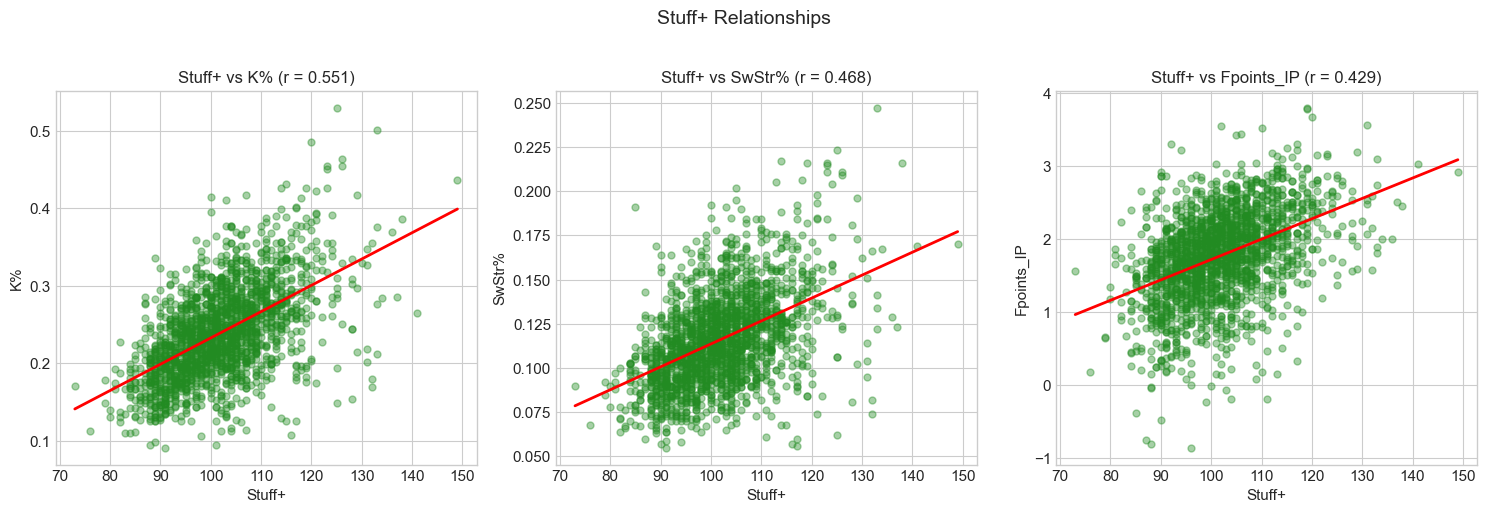

In [19]:
# Stuff+ vs other metrics
if 'Stuff+_lag1' in pitchers_df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    comparisons = [('Stuff+_lag1', 'K%_lag1'), ('Stuff+_lag1', 'SwStr%_lag1'), ('Stuff+_lag1', 'Fpoints_IP')]
    
    for i, (x, y) in enumerate(comparisons):
        if x in pitchers_df.columns and y in pitchers_df.columns:
            data = pitchers_df[[x, y]].dropna()
            axes[i].scatter(data[x], data[y], alpha=0.4, s=25, color='forestgreen')
            
            z = np.polyfit(data[x], data[y], 1)
            p = np.poly1d(z)
            x_line = np.linspace(data[x].min(), data[x].max(), 100)
            axes[i].plot(x_line, p(x_line), 'r-', linewidth=2)
            
            corr = data[x].corr(data[y])
            axes[i].set_xlabel('Stuff+')
            axes[i].set_ylabel(y.replace('_lag1', ''))
            axes[i].set_title(f'Stuff+ vs {y.replace("_lag1", "")} (r = {corr:.3f})', fontsize=12)
    
    plt.suptitle('Stuff+ Relationships', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('book/_static/images/pitcher_stuffplus.png', dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 3: Target Variable Analysis
---

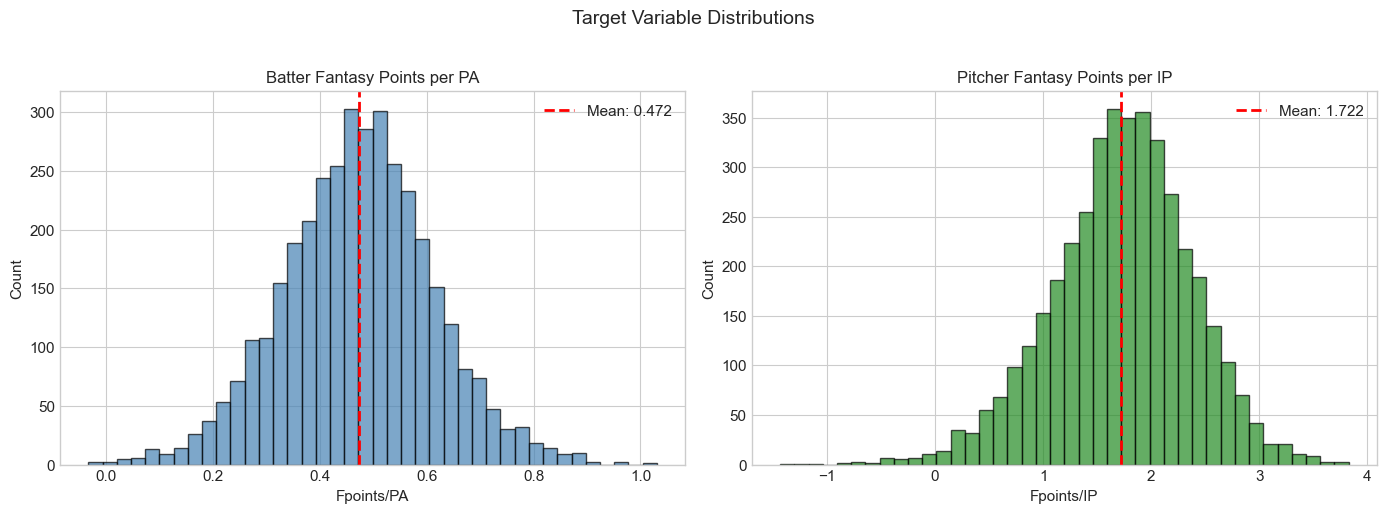

In [20]:
# Target distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Batter target
axes[0].hist(batters_df['Fpoints_PA'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(batters_df['Fpoints_PA'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Mean: {batters_df['Fpoints_PA'].mean():.3f}")
axes[0].set_title('Batter Fantasy Points per PA', fontsize=12)
axes[0].set_xlabel('Fpoints/PA')
axes[0].set_ylabel('Count')
axes[0].legend()

# Pitcher target
axes[1].hist(pitchers_df['Fpoints_IP'].dropna(), bins=40, edgecolor='black', alpha=0.7, color='forestgreen')
axes[1].axvline(pitchers_df['Fpoints_IP'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: {pitchers_df['Fpoints_IP'].mean():.3f}")
axes[1].set_title('Pitcher Fantasy Points per IP', fontsize=12)
axes[1].set_xlabel('Fpoints/IP')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Target Variable Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

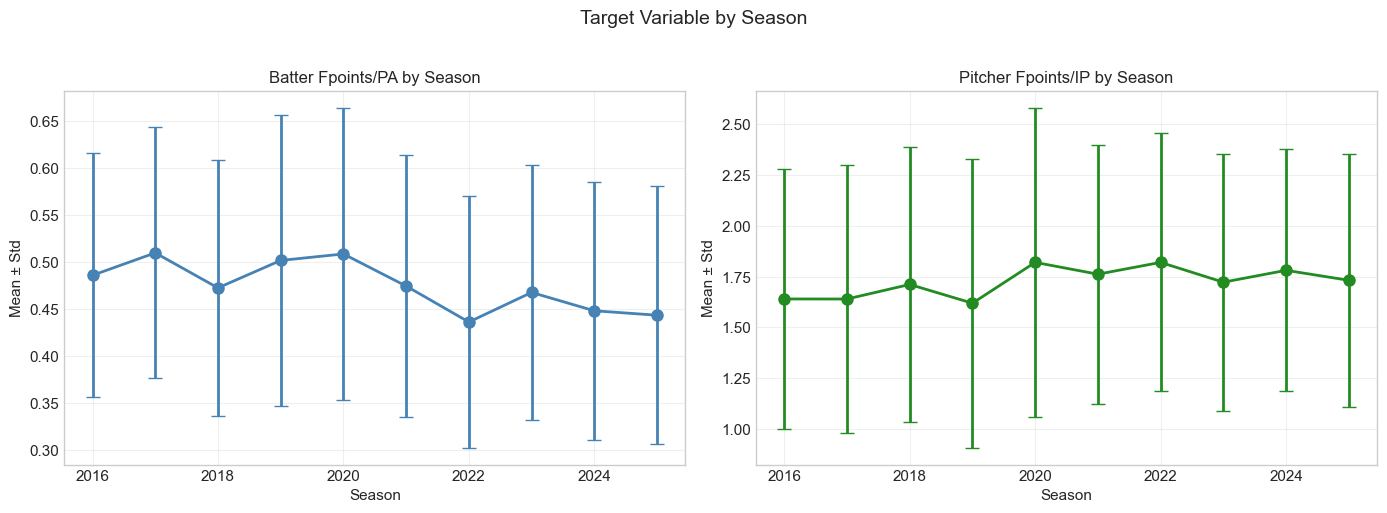

In [21]:
# Target by season
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Batter
bat_season = batters_df.groupby('Season')['Fpoints_PA'].agg(['mean', 'std'])
axes[0].errorbar(bat_season.index, bat_season['mean'], yerr=bat_season['std'],
                marker='o', capsize=5, linewidth=2, markersize=8, color='steelblue')
axes[0].set_title('Batter Fpoints/PA by Season', fontsize=12)
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Mean ± Std')
axes[0].grid(True, alpha=0.3)

# Pitcher
pit_season = pitchers_df.groupby('Season')['Fpoints_IP'].agg(['mean', 'std'])
axes[1].errorbar(pit_season.index, pit_season['mean'], yerr=pit_season['std'],
                marker='o', capsize=5, linewidth=2, markersize=8, color='forestgreen')
axes[1].set_title('Pitcher Fpoints/IP by Season', fontsize=12)
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Mean ± Std')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Target Variable by Season', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('book/_static/images/target_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary: All Saved Images

In [22]:
import os
images = sorted([f for f in os.listdir('book/_static/images') if f.endswith('.png')])
print(f"Total images saved: {len(images)}\n")
for img in images:
    size_kb = os.path.getsize(f'book/_static/images/{img}') / 1024
    print(f"  {img:40s} ({size_kb:.1f} KB)")

Total images saved: 23

  batter_age_curves.png                    (216.9 KB)
  batter_corr_full.png                     (208.4 KB)
  batter_corr_lag1.png                     (188.4 KB)
  batter_correlation.png                   (171.0 KB)
  batter_dendrogram.png                    (71.3 KB)
  batter_histograms.png                    (225.9 KB)
  batter_pairplot.png                      (492.8 KB)
  batter_scatter_target.png                (1064.3 KB)
  batter_season_trends.png                 (123.1 KB)
  batter_shap.png                          (237.4 KB)
  batter_trend_histograms.png              (225.6 KB)
  batter_yoy_stability.png                 (44.9 KB)
  pitcher_age_curves.png                   (221.8 KB)
  pitcher_corr_lag1.png                    (137.4 KB)
  pitcher_correlation.png                  (128.6 KB)
  pitcher_dendrogram.png                   (60.9 KB)
  pitcher_histograms.png                   (158.3 KB)
  pitcher_scatter_target.png               (886.2 KB)
  pitc